# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Haramain Rabbany
- Email: haramainr@gmail.com
- Id Dicoding: zimazat

## Persiapan

### Menyiapkan library yang dibutuhkan

In [174]:
# Import library utama untuk data processing
import pandas as pd
import numpy as np

# Library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk preprocessing & modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Model machine learning
from sklearn.ensemble import RandomForestClassifier

# Untuk menyimpan model
import joblib

### Menyiapkan data yang akan diguankan

## Data Understanding

In [175]:
# Load dataset (gunakan separator ;)
df = pd.read_csv('data.csv', sep=';')

# Tampilkan 5 data pertama
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [176]:
# Cek struktur data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [177]:
# Mengecek apakah ada data kosong
df.isnull().sum()

Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment                               0


Insight : Tidak ditemukan missing values pada dataset sehingga data dapat langsung digunakan untuk analisis lebih lanjut.

In [178]:
# Melihat jumlah masing-masing kategori
df['Status'].value_counts()

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [179]:
# Statistik dasar
df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


## Distribusi Target (status)

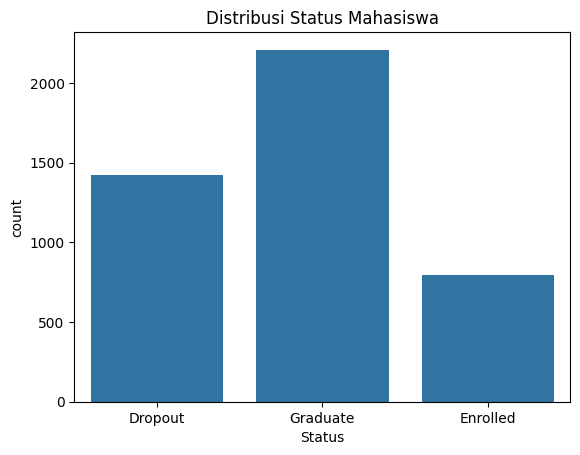

In [180]:
# Distribusi status mahasiswa
df['Status'].value_counts()

# Visualisasi
sns.countplot(x='Status', data=df)
plt.title('Distribusi Status Mahasiswa')
plt.show()

Insight : Dataset menunjukkan distribusi status mahasiswa yang terdiri dari dropout, graduate, dan enrolled. Distribusi ini penting untuk mengetahui apakah data seimbang atau tidak.

## Distribusi Fitur Numerik

Umur

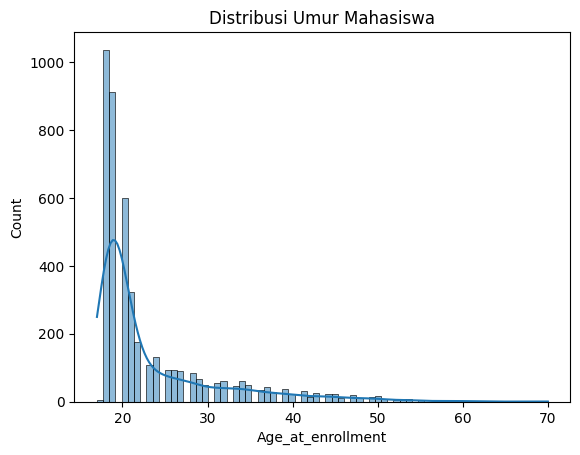

In [181]:
sns.histplot(df['Age_at_enrollment'], kde=True)
plt.title('Distribusi Umur Mahasiswa')
plt.show()

Admission Grade

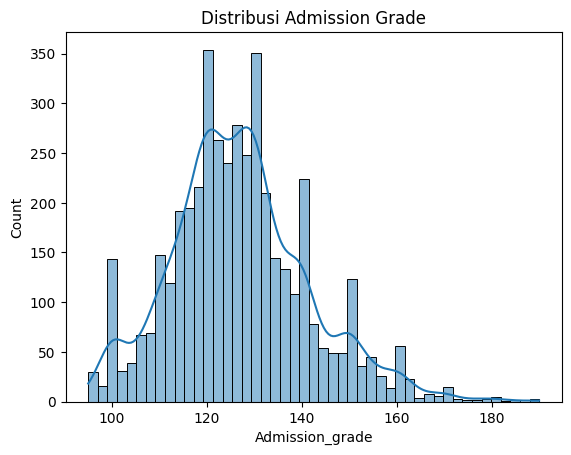

In [182]:
sns.histplot(df['Admission_grade'], kde=True)
plt.title('Distribusi Admission Grade')
plt.show()

Insight : Sebagian besar mahasiswa berada pada rentang usia tertentu. Nilai admission grade juga menunjukkan variasi yang dapat memengaruhi performa akademik.

## Hubungan Fitur dengan Target

Umur vs Status

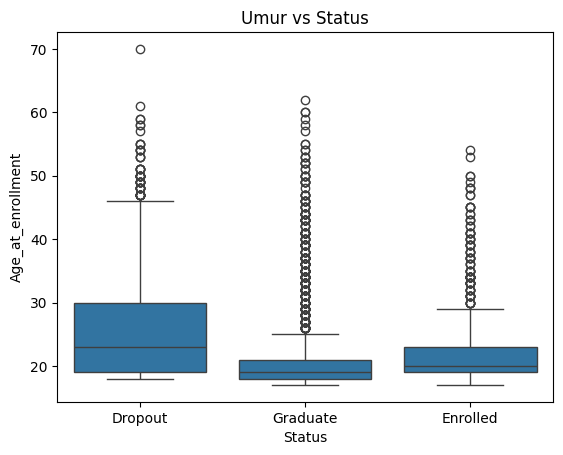

In [183]:
sns.boxplot(x='Status', y='Age_at_enrollment', data=df)
plt.title('Umur vs Status')
plt.show()

Nilai vs Status

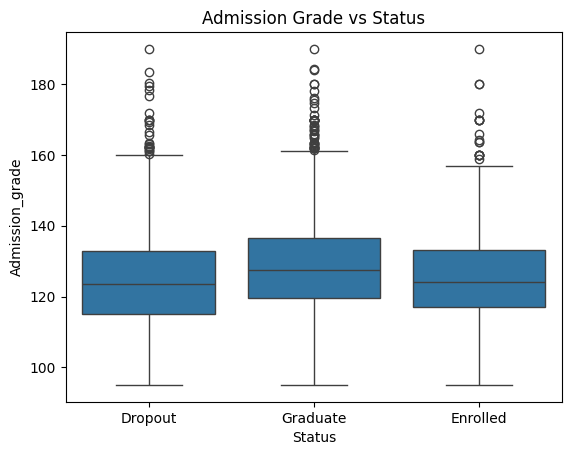

In [184]:
sns.boxplot(x='Status', y='Admission_grade', data=df)
plt.title('Admission Grade vs Status')
plt.show()

Insight : Mahasiswa dengan admission grade yang lebih rendah cenderung memiliki kemungkinan dropout lebih tinggi. Selain itu, terdapat perbedaan distribusi usia antar kategori status mahasiswa.

## Korelasi Antar Fitur

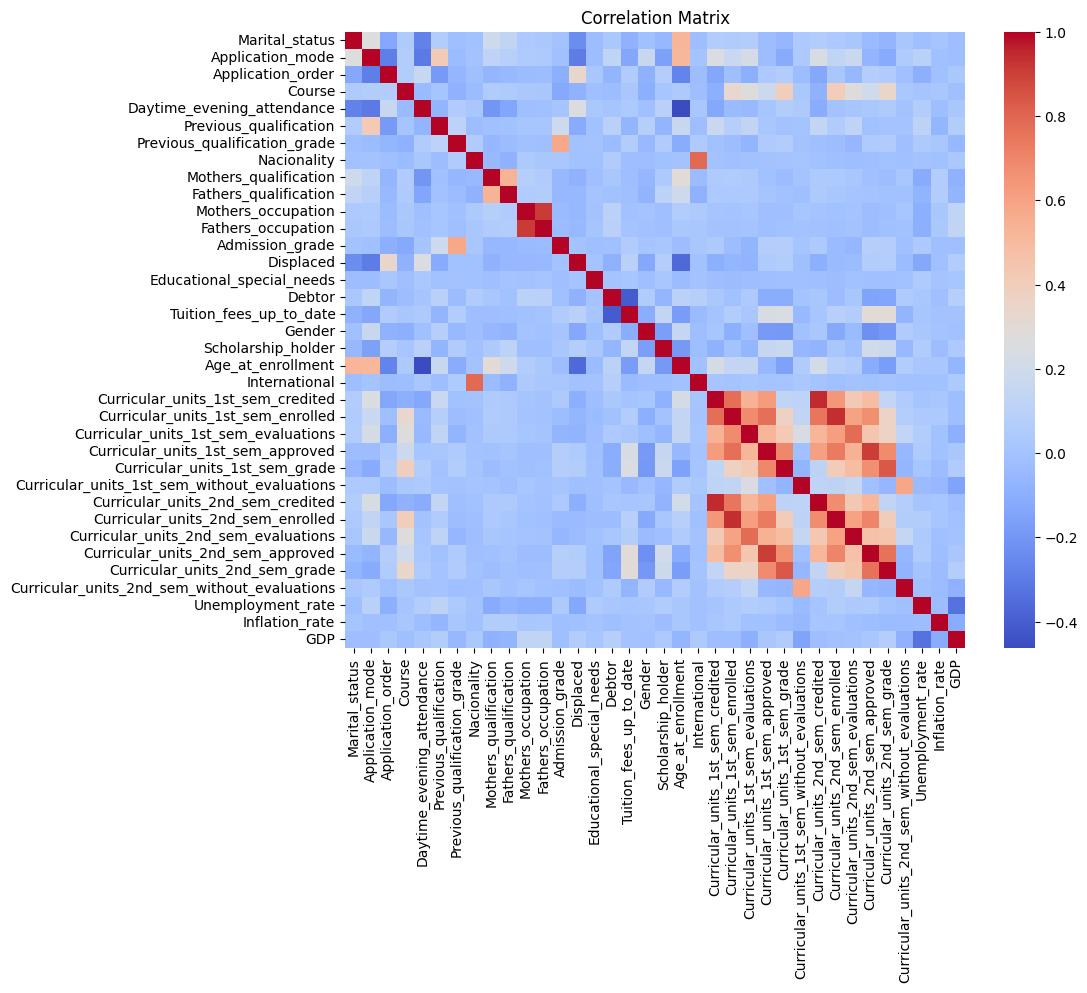

In [185]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Insight : Beberapa fitur memiliki korelasi yang cukup kuat satu sama lain, yang dapat menjadi indikator penting dalam membangun model prediksi.

## Rata-Rata IPK

In [186]:
# Rata-rata IPK semester 1 berdasarkan status
df.groupby('Status')['Curricular_units_1st_sem_grade'].mean()

Status
Dropout      7.256656
Enrolled    11.125257
Graduate    12.643655
Name: Curricular_units_1st_sem_grade, dtype: float64

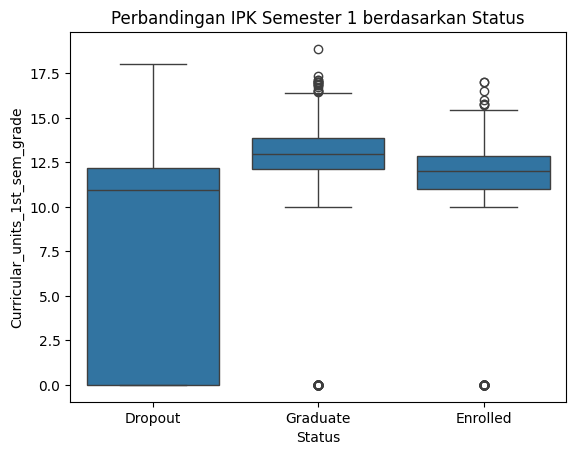

In [187]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Status', y='Curricular_units_1st_sem_grade', data=df)
plt.title('Perbandingan IPK Semester 1 berdasarkan Status')
plt.show()

Insight : Mahasiswa dengan status Dropout memiliki rata-rata IPK semester 1 yang lebih rendah dibandingkan mahasiswa Graduate.
Hal ini menunjukkan bahwa performa akademik awal menjadi indikator penting terhadap risiko dropout.

## Pembayaran UKT

In [188]:
# Distribusi status berdasarkan pembayaran
df.groupby('Tuition_fees_up_to_date')['Status'].value_counts(normalize=True)

Tuition_fees_up_to_date  Status  
0                        Dropout     0.865530
                         Enrolled    0.079545
                         Graduate    0.054924
1                        Graduate    0.559548
                         Dropout     0.247433
                         Enrolled    0.193018
Name: proportion, dtype: float64

Insight : Mahasiswa dengan status pembayaran tidak lancar (menunggak) memiliki proporsi dropout yang lebih tinggi dibandingkan mahasiswa yang membayar tepat waktu.
Faktor finansial menjadi salah satu penyebab utama mahasiswa tidak melanjutkan studi.

## Data Preparation / Preprocessing

In [189]:
# Copy dataset supaya data asli tidak berubah
df_clean = df.copy()

In [190]:
# Ubah skala nilai

df_clean['Admission_grade'] = df_clean['Admission_grade'] / 20
df_clean['Previous_qualification_grade'] = df_clean['Previous_qualification_grade'] / 20
df_clean['Curricular_units_1st_sem_grade'] = df_clean['Curricular_units_1st_sem_grade'] / 20

In [191]:
# Ambil hanya Dropout dan Graduate
df_model = df_clean[df_clean['Status'] != 'Enrolled'].copy()

# Mapping target ke numerik
df_model['Status'] = df_model['Status'].map({
    'Dropout': 0,
    'Graduate': 1
})

# Cek hasil
df_model['Status'].value_counts()

Status
1    2209
0    1421
Name: count, dtype: int64

Insight : Pada tahap ini, data dengan status "Enrolled" dihapus karena belum memiliki label akhir. Model difokuskan untuk memprediksi antara mahasiswa yang Dropout dan Graduate agar lebih sesuai dengan tujuan bisnis.

In [192]:
# Pilih fitur yang lebih lengkap
features = [
    #Akademik (inti)
    'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_1st_sem_enrolled',
    'Curricular_units_1st_sem_evaluations',

    #Nilai awal
    'Admission_grade',
    'Previous_qualification_grade',

    #Demografi
    'Age_at_enrollment',

    #Finansial
    'Tuition_fees_up_to_date',
    'Scholarship_holder'
]
X = df_model[features]
y = df_model['Status']

Insight : Fitur dipilih berdasarkan relevansi terhadap performa akademik dan faktor demografis yang dapat mempengaruhi kemungkinan mahasiswa dropout.

In [193]:
# Split data
X = df_model[features]
y = df_model['Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [194]:
# Melakukan normalisasi data menggunakan StandardScaler
scaler = StandardScaler()

# Fit scaler hanya pada data training, lalu transform ke keduanya
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Insight : Encoding dilakukan untuk mengubah data kategorikal menjadi numerik agar dapat diproses oleh algoritma machine learning.
Selain itu, normalisasi dilakukan untuk menyamakan skala antar fitur sehingga model dapat bekerja lebih optimal.

## Modeling

Pada tahap ini dilakukan pembangunan model machine learning untuk memprediksi status mahasiswa. Model yang digunakan adalah Random Forest Classifier karena memiliki performa yang baik pada data tabular dan mampu menangani kompleksitas data.

In [195]:
# Inisialisasi model
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

# Training
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [196]:
# Melakukan prediksi pada data testing
y_pred = model.predict(X_test)

In [197]:
# Melihat fitur paling berpengaruh
feature_importances = pd.Series(model.feature_importances_, index=X.columns)

# Urutkan dari yang terbesar
feature_importances = feature_importances.sort_values(ascending=False)

# Tampilkan 10 fitur teratas
feature_importances.head(10)

Curricular_units_1st_sem_approved       0.343421
Curricular_units_1st_sem_grade          0.210341
Tuition_fees_up_to_date                 0.123060
Admission_grade                         0.069329
Age_at_enrollment                       0.061299
Curricular_units_1st_sem_evaluations    0.055126
Curricular_units_1st_sem_enrolled       0.052185
Previous_qualification_grade            0.052031
Scholarship_holder                      0.033209
dtype: float64

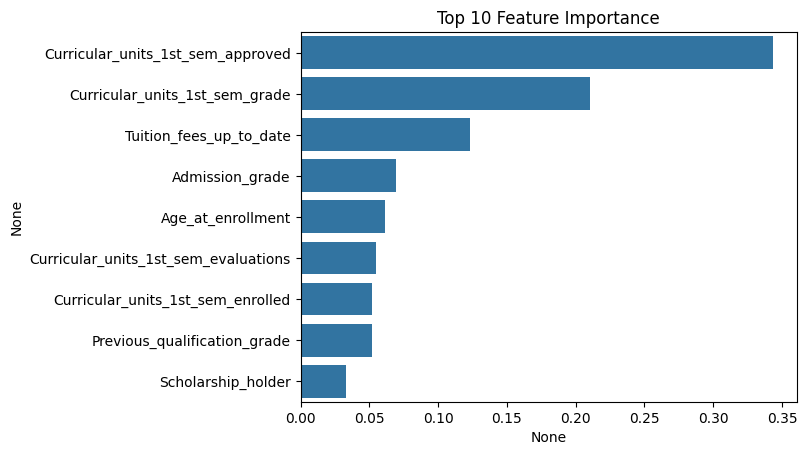

In [198]:
# Visualisasi fitur penting
sns.barplot(x=feature_importances.head(10), y=feature_importances.head(10).index)
plt.title('Top 10 Feature Importance')
plt.show()

Insight : Berdasarkan hasil feature importance, terdapat beberapa fitur yang memiliki pengaruh besar terhadap prediksi status mahasiswa. Fitur-fitur ini dapat menjadi indikator penting dalam mendeteksi kemungkinan mahasiswa mengalami dropout.

## Evaluation

Pada tahap ini dilakukan evaluasi model untuk mengetahui performa model dalam memprediksi apakah mahasiswa akan dropout atau graduate.

In [199]:
# Train model
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Menampilkan hasil evaluasi model
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.76      0.82       277
           1       0.86      0.95      0.90       449

    accuracy                           0.87       726
   macro avg       0.88      0.85      0.86       726
weighted avg       0.88      0.87      0.87       726



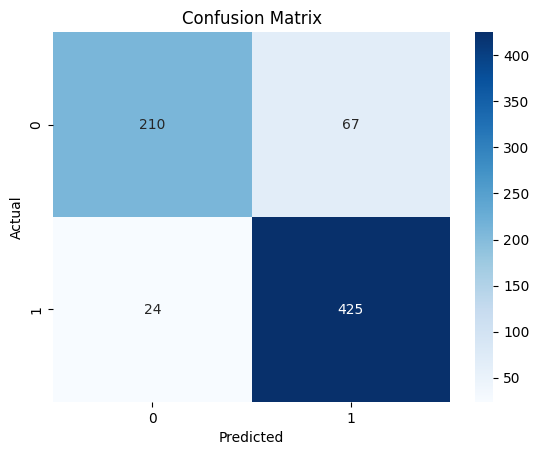

In [200]:
# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualisasi confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# Label dan judul
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Menampilkan plot
plt.show()

In [201]:
from sklearn.metrics import accuracy_score

# Menghitung akurasi
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8746556473829201


Insight : Model menunjukkan performa yang cukup baik dalam memprediksi status mahasiswa.
Berdasarkan classification report, model mampu mengklasifikasikan sebagian besar data dengan akurasi yang baik.
Namun, masih terdapat beberapa kesalahan prediksi terutama pada kelas tertentu, yang dapat menjadi bahan evaluasi untuk pengembangan model selanjutnya.

Save Model & Scaler

In [202]:
# Menyimpan model ke file
joblib.dump(model, 'model.pkl')

# Menyimpan scaler (penting untuk preprocessing di app)
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

## Conclusion 

Berdasarkan hasil pemodelan yang telah dilakukan, model machine learning mampu memprediksi status mahasiswa (Dropout dan Graduate) dengan akurasi sebesar 87%.

Hasil evaluasi menunjukkan:
- Precision dan recall pada kedua kelas sudah cukup baik
- Recall untuk kelas Dropout sebesar 76%, menunjukkan model cukup mampu mengidentifikasi mahasiswa yang berisiko dropout
- Recall untuk kelas Graduate sebesar 95%, menunjukkan model sangat baik dalam mengenali mahasiswa yang akan lulus

Insight utama yang diperoleh:
- Performa akademik di semester pertama menjadi faktor paling berpengaruh terhadap kelulusan mahasiswa
- Mahasiswa dengan tunggakan pembayaran memiliki risiko dropout lebih tinggi
- Faktor akademik dan finansial merupakan indikator utama dalam menentukan status mahasiswa

Model ini dapat digunakan sebagai sistem early warning untuk membantu institusi pendidikan dalam melakukan intervensi lebih dini guna menekan angka dropout.

## Action Items

Berdasarkan hasil analisis data dan performa model machine learning, berikut rekomendasi yang dapat dilakukan oleh institusi:

1. Monitoring Mahasiswa Berisiko Tinggi  
   - Gunakan model machine learning untuk mengidentifikasi mahasiswa dengan probabilitas dropout tinggi sejak semester awal  

2. Intervensi Akademik Dini  
   - Fokus pada mahasiswa dengan performa akademik rendah di semester pertama  
   - Sediakan program mentoring dan bimbingan belajar tambahan  

3. Dukungan Finansial  
   - Prioritaskan bantuan kepada mahasiswa dengan status pembayaran tertunggak  
   - Perluas akses beasiswa untuk menekan risiko dropout  

4. Sistem Early Warning Terintegrasi  
   - Integrasikan model ke dalam dashboard monitoring untuk pemantauan real-time  
   - Gunakan hasil prediksi sebagai dasar pengambilan keputusan  

5. Evaluasi dan Pengembangan Model  
   - Lakukan retraining model secara berkala dengan data terbaru  
   - Tingkatkan performa model terutama dalam mendeteksi mahasiswa dropout